## GXBOOST

---------------------------------

### Pipeline:
- két adatbázis:
    - delta: csak a delta változókat tartalmazza, az alapadatokat nem (kör- és szektoridők, gumi kora, sebességek, stb.)
    - allvars:  szűrés nélkül az összes változót (ezek között van multikollinearitás)
- stratifikáció itt is a Stratify alapján
- Driverek és Teamek category típusú változóvá alakítítom
	- mapping használata a visszakövethetőségért
	- enable_categorical=True használata így KÖTELEZŐ
- 3 szöveges pipeline (stacking; célja az, hogy egy bonyolult, strukturálatlan szöveges adatot úgy csomagoljon össze egyetlen informatív, numerikus változóvá, hogy azt a fő modell optimálisan fel tudja használni):
	- az OutOfFold rész biztosítja, hogy ne legyen data leakage, az éppen futó modell ne lássa azt a konkrét megfigyelést, amire éppen tippel
	- TF-IDF + LogReg:
		- stacking (modell alapú jellemzőkészítő) eljárást hajt végre, amely a strukturálatlan szöveges adatokat TF-IDF kódolással és egy hiperparaméter-hangolt logisztikus regresszióval dolgozza fel. A túltanulás és az adatszivárgás elkerülése érdekében az eljárás Out-of-Fold (OOF) keresztvalidációval készít tisztított predikciókat a tanítóhalmazra. A folyamat végső célja, hogy a fa-alapú modellek számára nehezen emészthető, ritka és több ezer dimenziós szöveges információt egyetlen, könnyen kezelhető numerikus változóvá (valószínűséggé) sűrítse az XGBoost számára
	- TF-IDF + Naive Bayes
		- A naive bayes azért ideális választás erre az előkészítő lépésre, mert kiemelkedő hatékonysággal kezeli a ritka (sparse) szöveges adatokat, így stabil és informatív meta-jellemzőt hoz létre anélkül, hogy túlilleszkedne 
	- TargetEncoding: a változót számokká alakítja úgy, hogy a kategória értékeit a hozzájuk tartozó célváltozó átlagával helyettesíti
- 1. XGBClassifier:
	- itt még nem használok early_stoppingot, mert "A Scikit-learn beépített keresői (mint a RandomizedSearchCV vagy GridSearchCV) a Keresztvalidációt (CV) használják. A hagyományos CV során a modell K-szor tanul újra az adatok különböző részein. Ebbe nagyon nehézkes és kód-intenzív beépíteni a korai leállítást (early stopping) úgy, hogy minden foldnak legyen egy saját, független validációs halmaza."
	- ajánlott közepes méretű n_estimators használata
- CV felosztás stratifikáltan
- RS és paraméter-eloszlások meghatározása
- RS alapján első illesztés
- train + validációs split
- RS illesztés a legjobb pm-ekkel
- 2. XGBClassifier
	- irrálisan magas n_estimators
	- early_stopping_rounds itt kerül bele
- ennek illesztése

Miért volt erre szükség?

1. Fázis: A legjobb "tanulási módszer" megtalálása (Hiperparaméter-hangolás)
Mielőtt a diák leülne magolni, ki kell találnunk, hogy milyen módszerrel tanul a leghatékonyabban. Olvasson sokat, vagy inkább kevesebbet, de azt alaposabban? (A modellnél ezek a "fák" tulajdonságai: milyen mélyek legyenek, milyen gyorsan tanuljanak, stb.)

	- Mi történik? Kipróbálunk rengeteg különböző beállítást (ez a Random Search). Hogy ne tartson örökké a próbaidőszak, egy közepes, fix "könyvmennyiséget" (100-200 fa) adunk neki.

	- A trükk: Hogy biztosra menjünk, a gyakorló feladatokat (adatokat) több részre osztjuk, és folyamatosan cserélgetjük, min vizsgáztatjuk a próbák során (ez a Keresztvalidáció / Cross-Validation).

	- Az eredmény: A fázis végére megkapjuk a tökéletes tanulási stratégiát (a legjobb beállításokat).

2. Fázis: Mikor hagyja abba a tanulást? (Az Early Stopping logikája)
Megvan a tökéletes módszer, de van egy óriási veszély: ha a diák túl sokat gyakorol ugyanazon a feladatsoron, akkor nem a logikát fogja megérteni, hanem egyszerűen kívülről betanulja a válaszokat (ez a túltanulás, vagy overfitting). Ha viszont túl keveset tanul, buta marad.

	- Mi történik? Hogy ezt elkerüljük, a megmaradt gyakorló feladatokat kettévágjuk. Az egyik feléből ténylegesen tanulni fog (Train halmaz), a másik felét viszont elzárjuk előle, ez lesz a "próbavizsga" (Validációs halmaz).

	- A trükk: A diák elkezd tanulni, és minden egyes elolvasott fejezet (minden egyes új fa felépítése) után megíratunk vele egy próbavizsgát a korábban elzárt kérdésekből.

	- A leállítás (Early Stopping): Amíg a próbavizsgán egyre jobb jegyeket kap, hagyjuk tovább tanulni. De abban a pillanatban, amikor azt látjuk, hogy hiába olvasott el újabb 30 fejezetet, a próbavizsga eredménye már nem javul (vagy egyenesen romlik, mert elkezdte bemagolni az előzőeket), kivesszük a kezéből a könyvet.

Az eredmény: Pontosan a megfelelő mennyiségű tudást szívta magába, megkaptuk az ideális, végleges modellt.

- predikció:
	- értékre
	- valségre
- teljesítménymutatók kiszámolása és elmentése:
	- F1
	- AUC
	- BCE
	- Brier-score
	- CV mean és std (ábrázolás is)
	- confusion matrix (ábrázolása is)
- ROC és kalibrációs görbe ábrázolása és elmentése
- Feature importance számolása, ábrázolása és elmentése

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (mean_squared_error, f1_score, roc_auc_score,
                             log_loss, brier_score_loss, accuracy_score,
                             RocCurveDisplay, confusion_matrix)
from sklearn.calibration import CalibrationDisplay
from scipy.stats import uniform, randint, loguniform

import xgboost as xgb
import sklearn

In [2]:
# MELYIKET HASZNÁLOD ???

df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_clean_delta_2laps.parquet')
dataset = 'delta'

#ebben megmarad a TrackDescription:
#df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_allvars_2laps.parquet')
#dataset = 'allvars'

#df = pd.read_parquet('C:/Users/tobakbalazs/egyetem/ELTE/IV/01_Szakdolgozat/Python_R/models/final_allvars_wo_corners_2laps.parquet')
#dataset = 'allvars_wocorners'

In [3]:
target_col = 'Sikeres'
cat_cols = ['Driver_Overtaker', 'Driver_Passed', 'Team_Passed', 'Team_Overtaker']

# Kombinált stratifikációs változó létrehozása
#df['Stratify_Combined'] = df[target_col].astype(str) + "_" + df.get('Stratify', pd.Series(index=df.index, dtype=str)).astype(str)

In [4]:
#Driverek és Teamek CATEGORY-vá alakítása

mappings = {}
for col in cat_cols:
    # Kategóriatípusra alakítás
    df[col] = df[col].astype('category')
    
    # Ha később szükséged van a kategóriák listájára a visszakereséshez:
    mappings[col] = dict(enumerate(df[col].cat.categories))

In [5]:
# Feature és target szétválasztása
X = df.drop(columns=[target_col, 'Stratify'], errors='ignore')
y = df[target_col]
strat_col = df['Stratify']

# Train-test split a kombinált stratifikáció alapján
X_train, X_test, y_train, y_test, strat_train, strat_test = train_test_split(
    X, y,
    strat_col,
    test_size=0.2,
    stratify=strat_col,
    random_state=42
)

In [6]:
# LR + TF-IDF
# 1. A szöveges Pipeline definiálása (csak a szövegre)
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

param_dist = {
    'tfidf__max_features': [100, 300, 500],
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
    'tfidf__stop_words': [None, 'english'],
    'logreg__class_weight': [None, 'balanced'],
    'logreg__C': loguniform(1e-4, 1e+2),      # 0.0001-től 100-ig keres logaritmikus skálán
    'logreg__penalty': ['l2', 'l1'],          # Kipróbálja mindkettőt
    'logreg__solver': ['saga']               # A saga támogatja az l1-et és l2-t is
}

random_search = RandomizedSearchCV(
    text_pipeline, 
    param_distributions=param_dist, 
    n_iter=20,     
    cv=5, 
    scoring='roc_auc', 
    random_state=42,    
    n_jobs=-1
)

random_search.fit(X_train['TrackDescription'], y_train)

best_pipe = random_search.best_estimator_

#Out-of-Fold predikciók a tanítóhalmazra 
oof_train_proba = cross_val_predict(
    best_pipe, 
    X_train['TrackDescription'], 
    y_train, 
    cv=5,                
    method='predict_proba', #kérjük a valószínűségeket
    n_jobs=-1
)[:, 1] #sikerest nézzük

best_pipe.fit(X_train['TrackDescription'], y_train)

test_proba = best_pipe.predict_proba(X_test['TrackDescription'])[:, 1]

X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

#itt adjuk át a számokat
X_train_ext['TrackDesc_LR'] = oof_train_proba 
X_test_ext['TrackDesc_LR'] = test_proba

X_train_ext = X_train_ext.drop(columns=['TrackDescription'])
X_test_ext = X_test_ext.drop(columns=['TrackDescription'])

print(f"LogReg Test AUC: {roc_auc_score(y_test, test_proba):.4f}")

LogReg Test AUC: 0.5912


In [7]:
# XGBoost osztályozó definiálása
#earlystopping kikerült

clf = xgb.XGBClassifier(
    tree_method='hist',
    device='cpu',
    n_estimators=300, #ezt közepesre érdemes venni (100-500)
    enable_categorical=True,
    eval_metric='logloss',
    objective='binary:logistic',
    #early_stopping_rounds=50,
    importance_type='gain', #mennyivel javította a split a loss-t
    random_state=42
)

In [9]:
# Egyedi Cross-Validation iterátor a Stratify alapján történő rétegzéshez
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(skf.split(X_train_ext, strat_train))

In [10]:
#Paraméterek RS-hez
param_dist = {
    
    #alapkomplexitások
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(0.005, 0.3),
    'min_child_weight': randint(1, 15),
    
    #mintavételezés
    'subsample': uniform(0.5, 0.5),  # 0.6–1.0
    'colsample_bytree': uniform(0.5, 0.5),
    'colsample_bylevel': uniform(0.5, 0.5),
    
    #regularizáció
    'gamma': loguniform(1e-4, 5.0),
    'reg_alpha': loguniform(1e-4, 10.0), #L1 --> kevésbé fontos súlyokat 0-za
    'reg_lambda': loguniform(1e-3, 10.0) #L2 --> nem nullázza, de nem is egnedi túlnőni --> mindkettő hangolása: elastic net
}

In [11]:
#Random Search
random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=600, #ennyi tesztelési paraméterhez kell legalább 100-150
    cv=cv_splits,
    scoring='roc_auc',
    refit=True,
    verbose=1,
    n_jobs=-1, # MOST MINUSZ 1
    random_state=42
)

In [12]:
random_search.fit(X_train_ext, y_train)

Fitting 5 folds for each of 600 candidates, totalling 3000 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bylevel': <scipy.stats....002666ACBB9A0>, 'colsample_bytree': <scipy.stats....002666ACB8490>, 'gamma': <scipy.stats....002666ACBA6B0>, 'learning_rate': <scipy.stats....002666ACBBF40>, ...}"
,n_iter,600
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,"[(array([ 0, ..., 8376, 8377]), ...), (array([ 0, ..., 8376, 8377]), ...), ...]"
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [13]:
# Train + validációs split a teljes train halmazból (early stoppinghoz)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_ext, y_train,
    test_size=0.15,                    
    stratify=strat_train,
    random_state=42
)

In [14]:
# refit a legjobb paraméterekkel + early stopping
best_params = random_search.best_params_

In [15]:
best_model = xgb.XGBClassifier(
    **best_params,
    n_estimators=2000,
    early_stopping_rounds=40, # 20-50 között szoktam használni, 30 jó kompromisszum
    random_state=42,
    tree_method='hist',
    device='cpu',
    enable_categorical=True,
    eval_metric='logloss',
    importance_type='gain',
    objective='binary:logistic'
)

In [16]:
best_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    #eval_metric='logloss', #az előző cellában már megadttuk
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,0.9873965810733916
,colsample_bynode,None
,colsample_bytree,0.8251628431734684
,device,'cpu'
,early_stopping_rounds,40
,enable_categorical,True
,eval_metric,'logloss'


In [17]:
print(f"Early stopping megállt {best_model.best_iteration} fánál")
print(f"Best validation logloss: {best_model.best_score}")

Early stopping megállt 323 fánál
Best validation logloss: 0.14329344758015836


In [18]:
#Threshold optimalizálás F1 alapján

y_val_probs = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.35, 0.65, 0.01)

# 5. F1-score számítása minden küszöbre a validációs halmazon
f1_scores = [f1_score(y_val, (y_val_probs >= t).astype(int)) for t in thresholds]

# 6. A legjobb küszöb kiválasztása
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
best_f1 = f1_scores[ix]

print(f'Legjobb küszöb (a validációs halmazon): {best_threshold:.3f}')
print(f'Ezzel elért F1-score a validációs halmazon: {best_f1:.5f}')

Legjobb küszöb (a validációs halmazon): 0.490
Ezzel elért F1-score a validációs halmazon: 0.94304


In [19]:
# Predikciók
y_pred = best_model.predict(X_test_ext)
y_pred_proba = best_model.predict_proba(X_test_ext)[:, 1] #ez a valség

In [20]:
# Mutatók --> Y_PRED_PROBA
#rmse_val = mean_squared_error(y_test, y_pred_proba, squared=False)
f1_val = f1_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_pred_proba)
bce_val = log_loss(y_test, y_pred_proba)
brier_val = brier_score_loss(y_test, y_pred_proba)
cm_xgb = confusion_matrix(y_test, y_pred)

In [21]:
print(type(best_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [22]:
# CV Accuracy szórása a legjobb modellnél
best_index = random_search.best_index_
cv_accuracy_mean = random_search.cv_results_['mean_test_score'][best_index]
cv_accuracy_std = random_search.cv_results_['std_test_score'][best_index]

In [23]:
# Paraméterek száma (A Random Search által vizsgált/kiválasztott hiperparaméterek)
num_params = len(random_search.best_params_)

In [24]:
#KONKRÉT felhasznált paraméterek száma

# 1. Kinyerjük a modellt alkotó fák belső struktúráját egy DataFrame-be
booster = best_model.get_booster()
trees_df = booster.trees_to_dataframe()

# 2. Early stopping miatt a modell tovább tanult, mint a legjobb iteráció, 
# ezért csak azokat a fákat tartjuk meg, amiket a predikcióhoz ténylegesen használ
active_trees_df = trees_df[trees_df['Tree'] <= best_model.best_iteration]

# 3. Kiszámoljuk a paramétereket
# A levelek száma (leaf weights)
num_leaves = len(active_trees_df[active_trees_df['Feature'] == 'Leaf'])

# A vágások száma (split conditions: feature + threshold)
num_splits = len(active_trees_df[active_trees_df['Feature'] != 'Leaf'])

# Összes megtanult paraméter
total_parameters = num_leaves + num_splits

print(f"Levelek (kimeneti súlyok) száma: {num_leaves}")
print(f"Vágási pontok (döntési küszöbök) száma: {num_splits}")
print(f"---")
print(f"A modell összes megtanult paramétere: {total_parameters}")

Levelek (kimeneti súlyok) száma: 16021
Vágási pontok (döntési küszöbök) száma: 15697
---
A modell összes megtanult paramétere: 31718


In [23]:
# JSON formátumba rendezés (A numpy típusokat natív python típusokra konvertáljuk)
metrics_dict = {
    "ossz_param_szam": int(total_parameters),
    "levelek_szama": int(num_leaves),
    "vasasokszama": int(num_splits),
    "optimalizalt_parameterek_szama": int(num_params),
    "legjobb_parameterek": random_search.best_params_,
    'CV_atlag': float(cv_accuracy_mean),
    "CV_szorodas": float(cv_accuracy_std),
    "F1_score": float(f1_val),
    "AUC": float(auc_val),
    "Binaris_cross_entropy": float(bce_val),
    "Brier_score": float(brier_val),
    "Best_threshold": float(best_threshold)
}

# JSON mentése
with open(f'teljesitmenymutatok_retrain_{dataset}.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_dict, f, indent=4, ensure_ascii=False)

In [24]:
print('F1:', f1_val)
print('AUC:', auc_val)
print('BCE:', bce_val)
print('Brier-score:', brier_val)

F1: 0.9323479249573622
AUC: 0.9897385504800397
BCE: 0.1341519475492515
Brier-score: 0.039857948087559616


In [25]:
#CV mutatók alakulása a tanítás során
cv_results = pd.DataFrame(random_search.cv_results_)

cv_results[['mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head()

,mean_test_score,std_test_score,rank_test_score
157,0.985447,0.002265,1
58,0.984311,0.002234,2
51,0.982721,0.002206,3
442,0.982518,0.002612,4
320,0.982391,0.002742,5


In [26]:
print(type(best_model))

<class 'xgboost.sklearn.XGBClassifier'>


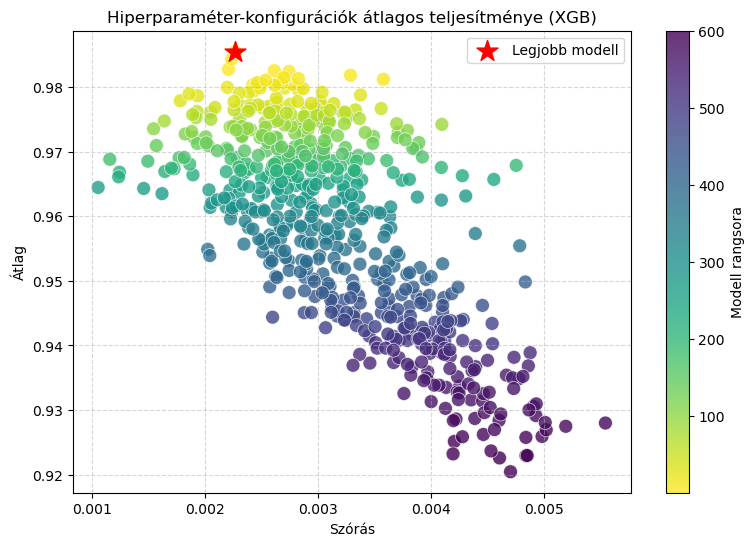

In [27]:
#CV mutatók alakulása a tanítás során + ábrázolás
cv_results = pd.DataFrame(random_search.cv_results_)

cv_results[['mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head()


plt.figure(figsize=(9, 6))

# Szóródiagram, ahol a szín a rangsort jelöli (minél kisebb a rank, annál sötétebb/másabb a szín)
scatter = plt.scatter(
    cv_results['std_test_score'],
    cv_results['mean_test_score'],
    c=cv_results['rank_test_score'],
    cmap='viridis_r', # Fordított viridis, hogy az 1-es helyezettek élénkek legyenek
    alpha=0.8,
    edgecolors='w', # Fehér keret a pontoknak a jobb elkülönülésért
    linewidth=0.5,
    s=100
)

# A legjobb modell megkeresése és kiemelése
best_cv_model = cv_results[cv_results['rank_test_score'] == 1].iloc[0]
plt.scatter(
    best_cv_model['std_test_score'], 
    best_cv_model['mean_test_score'],
    color='red', 
    marker='*', 
    s=250, # Nagy méret
    label='Legjobb modell',
    zorder=5 #hogy biztosan a többi pont felett jelenjen meg
)

# Színskála (Colorbar) hozzáadása
cbar = plt.colorbar(scatter)
cbar.set_label('Modell rangsora')

# Tengelyek és címek
plt.xlabel('Szórás')
plt.ylabel('Átlag')
plt.title('Hiperparaméter-konfigurációk átlagos teljesítménye (XGB)')

# Rács és jelmagyarázat
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Mentés és megjelenítés
plt.savefig(f'CV_alakulas_{dataset}_javitott.png', bbox_inches='tight', dpi=300)
plt.show()

#A pontok egy emelkedő trendet mutatnak: ahogy nő a modell jósága (Y-tengely), úgy nő vele együtt a bizonytalansága is (X-tengely).
#Ez a gépi tanulás klasszikus dilemmája: a komplexebb vagy kevésbé korlátozott modellek jobban teljesítenek, de sérülékenyebbek

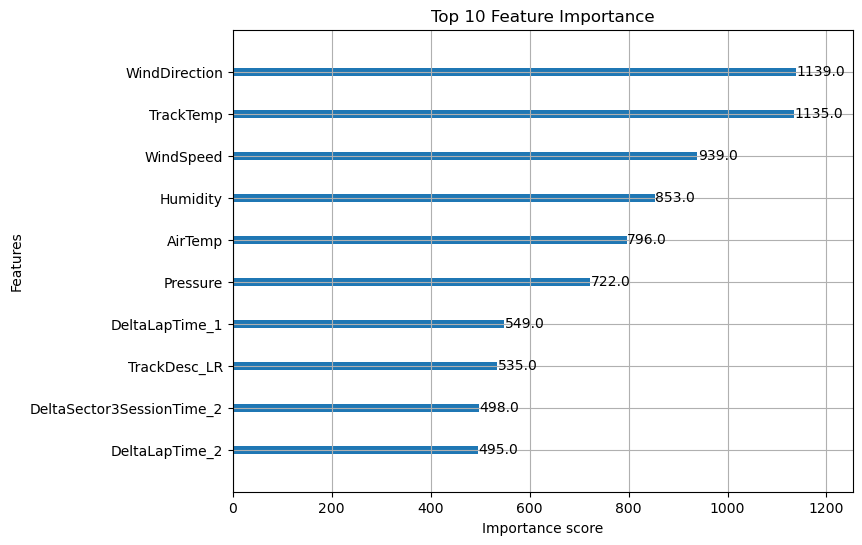

In [28]:
# Feature Importance

top_x = 10 

# Változónevek beállítása a modellen
feature_names = X_train_ext.columns.tolist()
best_model.get_booster().feature_names = feature_names

# 2. Létrehozunk egy konkrét ábra (fig) és tengely (ax) objektumot a kívánt mérettel
fig, ax = plt.subplots(figsize=(8, 6)) 

# 3. A plot_importance-nek átadjuk a max_num_features-t és a rajzvásznat (ax)
xgb.plot_importance(
    best_model, 
    max_num_features=top_x, 
    ax=ax,
    # importance_type='gain' # Opcionális: ha a default 'weight' helyett mást (pl. gain) vizsgálnál
)

plt.title(f'Top {top_x} Feature Importance')
plt.savefig(f'feature_importance_retrain_top10_{dataset}.png', bbox_inches='tight', dpi=300)
plt.show()

In [29]:
#FI előjelekkel:



<Figure size 800x600 with 0 Axes>

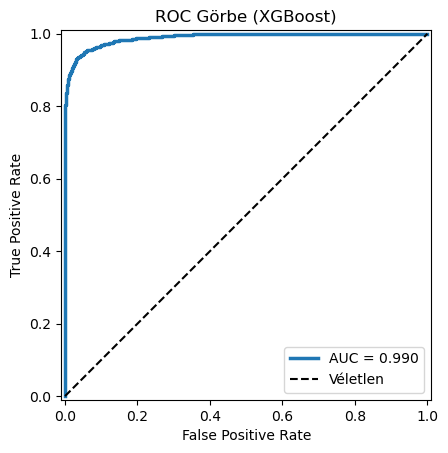

In [37]:
# ROC Görbe

plt.figure(figsize=(8, 6))

roc_disp = RocCurveDisplay.from_predictions(
    y_test, y_pred_proba, 
    curve_kwargs={'label': f'AUC = {auc_val:.3f}', 'linewidth': 2.5} 
)

plt.title('ROC Görbe (XGBoost)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Véletlen')
plt.legend()
plt.savefig(f'roc_gorbe_retrain_{dataset}.png', bbox_inches='tight', dpi=300)
plt.show()

<Figure size 800x600 with 0 Axes>

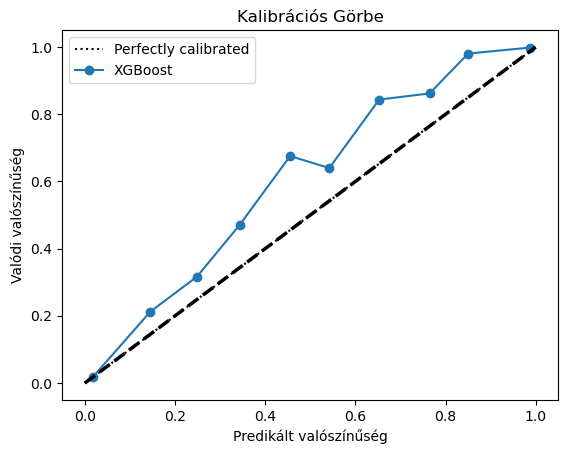

In [47]:
# Kalibrációs görbe

plt.figure(figsize=(8, 6))

CalibrationDisplay.from_predictions(y_test, y_pred_proba, n_bins=10, name='XGBoost', marker='o')

plt.plot([0, 1], [0, 1], 'k--', linewidth= 2.5)
plt.title('Kalibrációs Görbe')
plt.xlabel('Predikált valószínűség')
plt.ylabel('Valódi valószínűség')
plt.legend()
plt.savefig(f'kalibracios_gorbe_retrain_{dataset}.png', bbox_inches='tight', dpi=300)
plt.show()

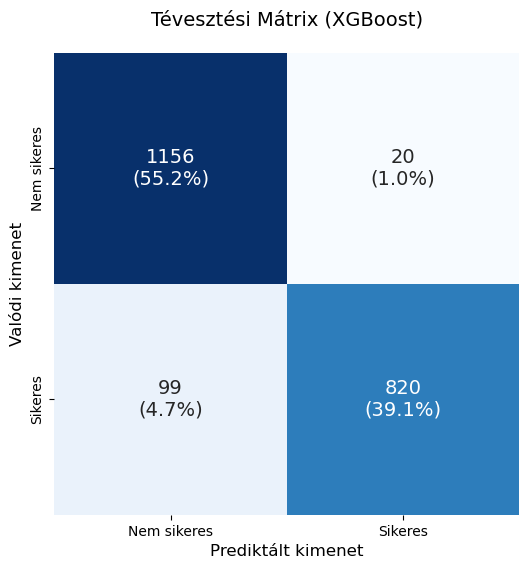

In [48]:
#Confusing matrix

cm_percentages_xgb = cm_xgb / np.sum(cm_xgb)

labels_xgb = [f"{count}\n({percent:.1%})" for count, percent in zip(cm_xgb.flatten(), cm_percentages_xgb.flatten())]
labels_xgb = np.asarray(labels_xgb).reshape(2, 2)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_xgb, annot=labels_xgb, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Nem sikeres', 'Sikeres'],
            yticklabels=['Nem sikeres', 'Sikeres'],
            annot_kws={"size": 14}) # A betűméretet itt tudod növelni

plt.xlabel('Prediktált kimenet', fontsize=12)
plt.ylabel('Valódi kimenet', fontsize=12)
plt.title("Tévesztési Mátrix (XGBoost)", fontsize=14, pad=20)

# Mentés és megjelenítés
plt.savefig(f"confusion_matrix_{dataset}.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
#elvileg ez meg fogja valahogy mondani, hogy melyik pilóta merre vitte a sikeresség valségét 
